In [30]:
import io
import re
import pandas as pd
import requests
from bs4 import BeautifulSoup

url = "https://en.wikipedia.org/wiki/List_of_largest_companies_by_revenue"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36"
}
response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")
table = soup.find("table", class_="wikitable")

df = pd.read_html(io.StringIO(str(table)))[0]

if isinstance(df.columns, pd.MultiIndex):
    df.columns = [" ".join(col).strip() for col in df.columns.values]

column_mapping = {}
for col in df.columns:
    c_lower = col.lower()
    if "rank" in c_lower:
        column_mapping[col] = "Rank"
    elif "name" in c_lower or "company" in c_lower:
        column_mapping[col] = "Company"
    elif "industry" in c_lower:
        column_mapping[col] = "Industry"
    elif "revenue" in c_lower:
        column_mapping[col] = "Revenue (USD)"
    elif "profit" in c_lower:
        column_mapping[col] = "Profit (USD)"
    elif "employee" in c_lower:
        column_mapping[col] = "Employees"
    elif "headquarters" in c_lower or "country" in c_lower:
        column_mapping[col] = "Country"

df = df.rename(columns=column_mapping)
required_cols = [
    "Rank",
    "Company",
    "Country",
    "Industry",
    "Revenue (USD)",
    "Profit (USD)",
    "Employees",
]
df = df[[col for col in required_cols if col in df.columns]]


def clean_numeric(val):
    if pd.isna(val):
        return None
    val_str = str(val)
    val_str = re.sub(r"\[.*?\]", "", val_str)
    val_str = (
        val_str.replace(",", "")
        .replace("$", "")
        .replace("€", "")
        .replace("£", "")
        .strip()
    )

    if val_str.startswith("(") and val_str.endswith(")"):
        val_str = "-" + val_str[1:-1]

    match = re.search(r"[-+]?\d*\.?\d+", val_str)
    return float(match.group()) if match else None


def clean_text(val):
    if pd.isna(val):
        return ""

    val = re.sub(r"\[.*?\]", "", str(val))
    return val.strip()


for col in ["Company", "Country", "Industry"]:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

for col in ["Rank", "Revenue (USD)", "Profit (USD)", "Employees"]:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

df = df.dropna(subset=["Revenue (USD)"])

df["Rank"] = df["Rank"].astype("Int64")
df["Employees"] = df["Employees"].astype("Int64")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

df.to_csv("largest_companies.csv", index=False)

print("File successfully saved as largest_companies.csv!\n")
print(df.head())

File successfully saved as largest_companies.csv!

   Rank                               Company        Country                        Industry  Revenue (USD)  Profit (USD)  Employees
0     1                                Amazon  United States  Retail  Information technology          716.0          79.9    1576000
1     2                               Walmart  United States                          Retail          713.0          21.8    2100000
2     3       State Grid Corporation of China          China                     Electricity          545.0           9.2    1361423
3     4                          Saudi Aramco   Saudi Arabia                     Oil and gas          480.0         106.0      73311
4     5  China National Petroleum Corporation          China                     Oil and gas          476.0          25.2    1026301


/tmp/ipykernel_683/2878437639.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_revenue, x="Revenue (USD)", y="Company", palette="Blues_r")


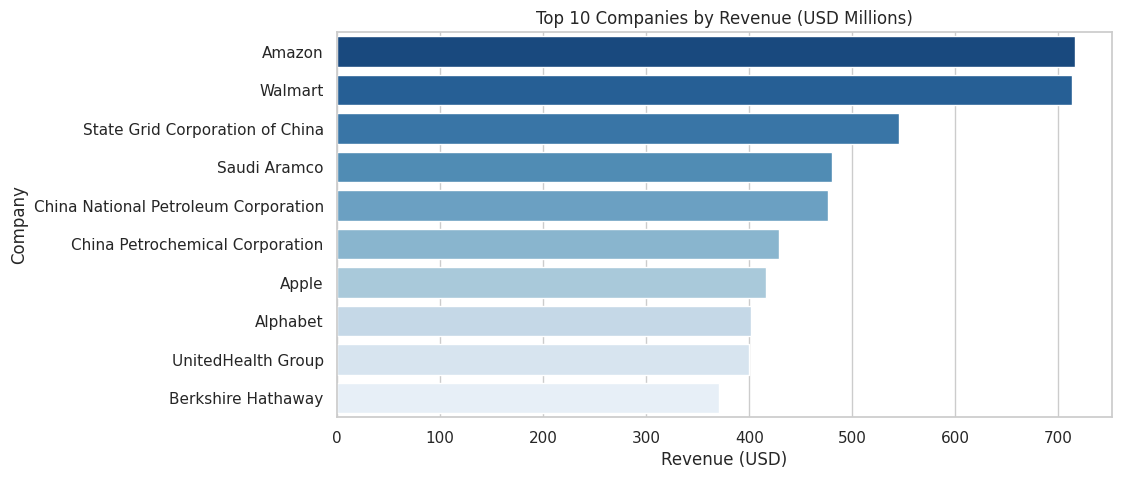

/tmp/ipykernel_683/2878437639.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_profit, x="Profit (USD)", y="Company", palette="Greens_r")


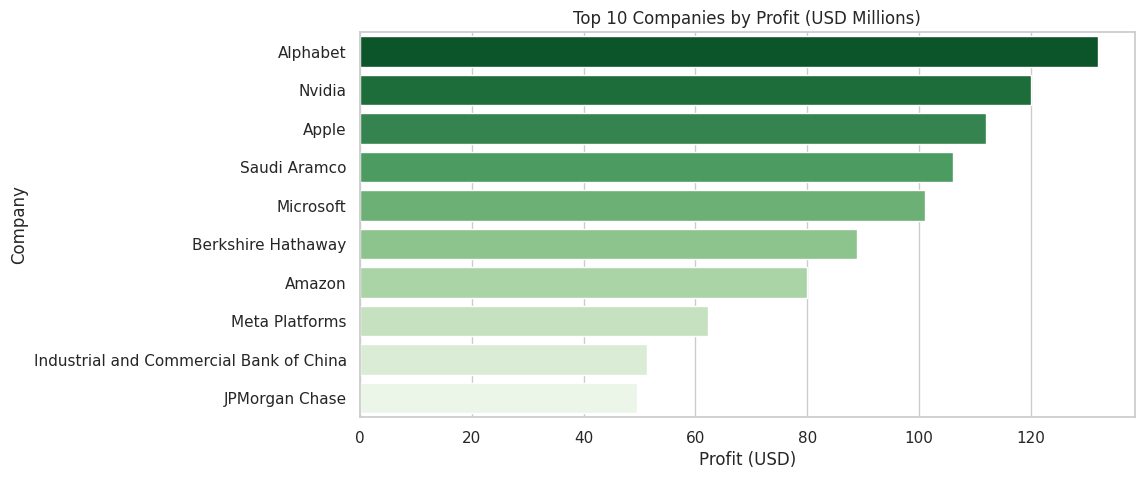

/tmp/ipykernel_683/2878437639.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette="mako")


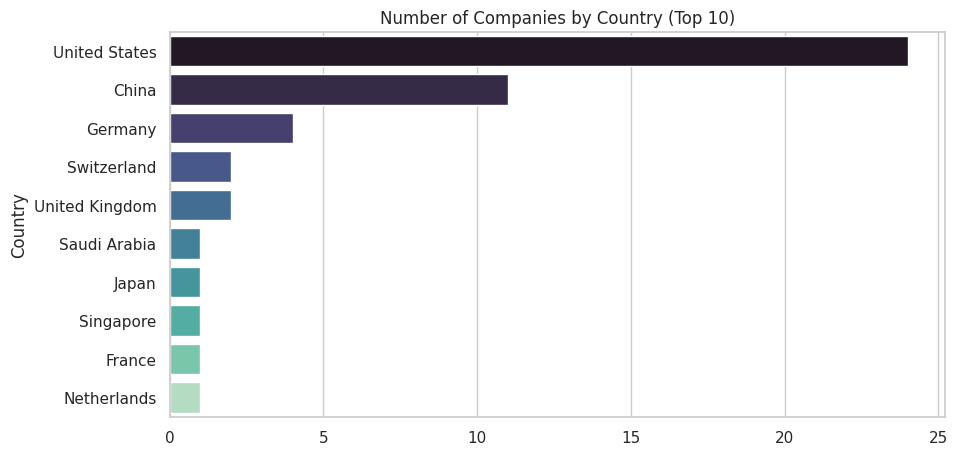

/tmp/ipykernel_683/2878437639.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.values, y=industry_counts.index, palette="rocket")


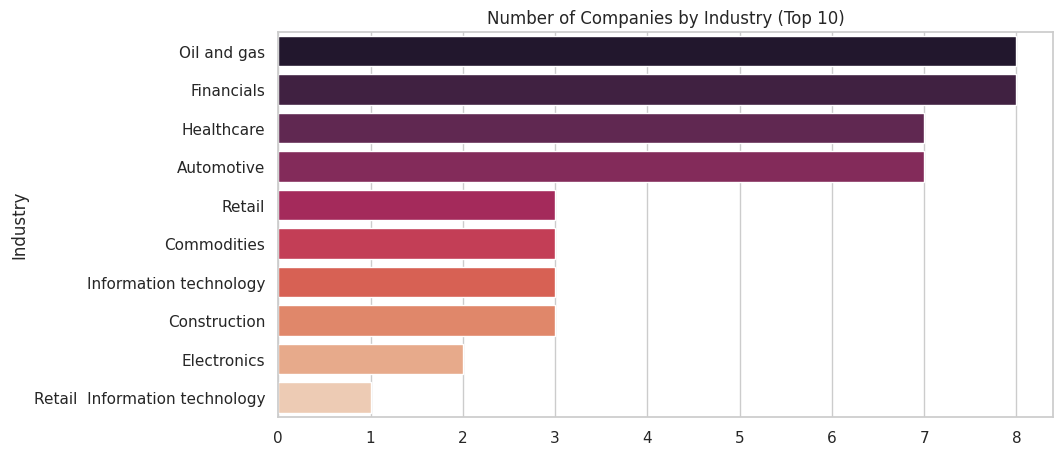

/tmp/ipykernel_683/2878437639.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rev_industry.values, y=avg_rev_industry.index, palette="crest")


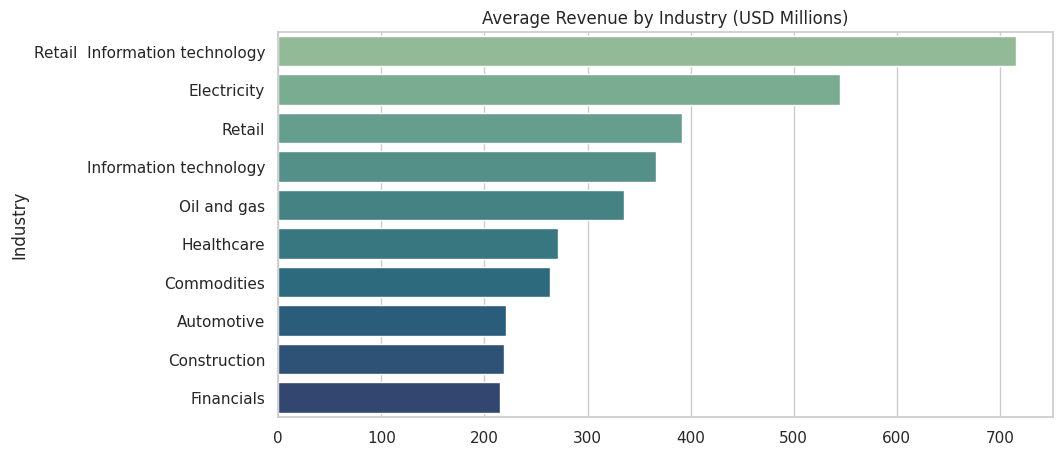

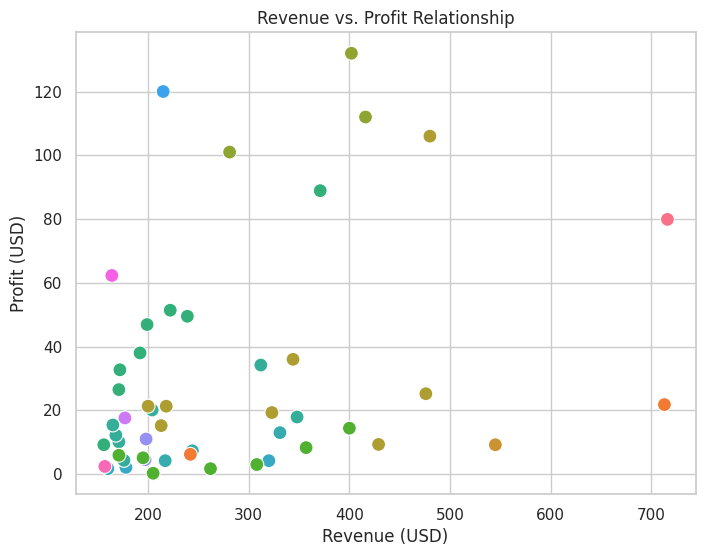

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("largest_companies.csv")

top10_revenue = df.nlargest(10, "Revenue (USD)")
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_revenue, x="Revenue (USD)", y="Company", palette="Blues_r")
plt.title("Top 10 Companies by Revenue (USD Millions)")
plt.show()

top10_profit = df.nlargest(10, "Profit (USD)")
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_profit, x="Profit (USD)", y="Company", palette="Greens_r")
plt.title("Top 10 Companies by Profit (USD Millions)")
plt.show()

plt.figure(figsize=(10, 5))
country_counts = df["Country"].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index, palette="mako")
plt.title("Number of Companies by Country (Top 10)")
plt.show()

plt.figure(figsize=(10, 5))
industry_counts = df["Industry"].value_counts().head(10)
sns.barplot(x=industry_counts.values, y=industry_counts.index, palette="rocket")
plt.title("Number of Companies by Industry (Top 10)")
plt.show()

plt.figure(figsize=(10, 5))
avg_rev_industry = (
    df.groupby("Industry")["Revenue (USD)"]
    .mean()
    .nlargest(10)
    .sort_values(ascending=False)
)
sns.barplot(x=avg_rev_industry.values, y=avg_rev_industry.index, palette="crest")
plt.title("Average Revenue by Industry (USD Millions)")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Revenue (USD)",
    y="Profit (USD)",
    hue="Industry",
    legend=False,
    s=100,
)
plt.title("Revenue vs. Profit Relationship")
plt.show()